In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

In [ ]:
IMAGE_SIZE = 299

BATCH_SIZE = 185
CHANNELS = 3
EPOCH = 50

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/SkinClassification/dataset/DATA/train",
    shuffle= True,
    image_size= (IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE

)

In [ ]:
len(dataset)

In [ ]:
class_names= dataset.class_names
class_names

In [ ]:
def get_dataset(ds, train_split = 0.8, val_split= 0.2, shuffle= True, shuffle_size= 10000):

  ds_size = len(ds)

  if shuffle:
    ds= ds.shuffle(shuffle_size, seed=12)

  train_size = int(ds_size*train_split)
  val_size = int(ds_size*val_split)

  train_ds= ds.take(train_size)
  val_ds= ds.skip(train_size)



  return train_ds, val_ds

In [ ]:
train_ds, val_ds= get_dataset(dataset)

In [ ]:
train_ds= train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds= val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [ ]:
resize_and_rescale= tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)

])

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(weights='imagenet', include_top=False)
base_model.trainable = False
x= resize_and_rescale
x= data_augmentation
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)

predictions = Dense(5, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer= 'adam',
    loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
    metrics=['accuracy']
)

In [ ]:
model.summary()

In [ ]:
# model.compile(
#     optimizer= 'adam',
#     loss= tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
#     metrics=['accuracy']
# )

In [ ]:
history= model.fit(
    train_ds,
    epochs= EPOCH,
    batch_size= BATCH_SIZE,
    verbose=1,
    validation_data= val_ds
)

In [ ]:
test_ds= tf.keras.preprocessing.image_dataset_from_directory(
    "/content/drive/MyDrive/SkinClassification/dataset/DATA/testing",
    shuffle= True,
    image_size= (IMAGE_SIZE, IMAGE_SIZE),
    batch_size= BATCH_SIZE
)

In [ ]:
model.evaluate(test_ds)

In [ ]:
acc= history.history['accuracy']
val_acc= history.history['val_accuracy']

loss= history.history['loss']
val_loss= history.history['val_loss']

In [ ]:
plt.figure(figsize= (10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCH), acc, label= 'Training Accuracy')
plt.plot(range(EPOCH), val_acc, label= 'Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

In [ ]:
plt.figure(figsize= (10,10))
plt.subplot(1,2,1)
plt.plot(range(EPOCH), loss, label= 'Training Loss')
plt.plot(range(EPOCH), val_loss, label= 'Validation Loss')
plt.legend(loc='lower right')
plt.title('Training and Validation loss')

In [ ]:
for image_batch, label_batch in test_ds.take(1):
  first_image= image_batch[0].numpy().astype('uint8')
  first_label= label_batch[0].numpy()


  print("First image to predict:")
  plt.imshow(first_image)
  print("Actual Label: ", class_names[first_label])
  batch_prediction= model.predict(image_batch)
  print("Predicted Label: ", class_names[np.argmax(batch_prediction[0])])

In [ ]:
def predict(model, img):
  img_array= tf.keras.preprocessing.image.img_to_array(images[i].numpy())
  img_array= tf.expand_dims(img_array, 0)

  predictions= model.predict(img_array)

  predicted_class= class_names[np.argmax(predictions[0])]

  return predicted_class

In [ ]:
history_pred_class= np.array([])
history_actual_class= np.array([])

plt.figure(figsize=(20,120))
for images, labels in test_ds.take(1):
  for i in range(185):
    ax= plt.subplot(37,5, i+1)
    plt.imshow(images[i].numpy().astype("uint8"))

    predicted_class= predict(model, images[i].numpy())
    actual_class= class_names[labels[i]]

    history_pred_class= np.append(history_pred_class, predicted_class)
    history_actual_class= np.append(history_actual_class, actual_class)

    plt.title(f"Actual: {actual_class}, \n Predicted: {predicted_class}.")
    plt.axis("off")

In [ ]:
history_actual_class

array(['Eczemaa', 'Actinic Keratosis', 'Rosacea', 'Eczemaa', 'Eczemaa',
       'Rosacea', 'Rosacea', 'Acne', 'Basal Cell Carcinoma',
       'Actinic Keratosis', 'Actinic Keratosis', 'Acne', 'Eczemaa',
       'Basal Cell Carcinoma', 'Rosacea', 'Basal Cell Carcinoma',
       'Eczemaa', 'Eczemaa', 'Rosacea', 'Basal Cell Carcinoma', 'Acne',
       'Basal Cell Carcinoma', 'Actinic Keratosis', 'Actinic Keratosis',
       'Eczemaa', 'Rosacea', 'Rosacea', 'Acne', 'Basal Cell Carcinoma',
       'Basal Cell Carcinoma', 'Eczemaa', 'Acne', 'Actinic Keratosis',
       'Eczemaa', 'Basal Cell Carcinoma', 'Acne', 'Actinic Keratosis',
       'Actinic Keratosis', 'Rosacea', 'Rosacea', 'Acne',
       'Basal Cell Carcinoma', 'Rosacea', 'Actinic Keratosis', 'Rosacea',
       'Acne', 'Rosacea', 'Rosacea', 'Acne', 'Rosacea', 'Rosacea',
       'Eczemaa', 'Eczemaa', 'Basal Cell Carcinoma', 'Actinic Keratosis',
       'Acne', 'Acne', 'Acne', 'Basal Cell Carcinoma',
       'Basal Cell Carcinoma', 'Rosacea', 'Bas

In [ ]:
history_pred_class

array(['Actinic Keratosis', 'Acne', 'Rosacea', 'Eczemaa', 'Eczemaa',
       'Rosacea', 'Rosacea', 'Acne', 'Basal Cell Carcinoma',
       'Actinic Keratosis', 'Basal Cell Carcinoma', 'Acne', 'Eczemaa',
       'Basal Cell Carcinoma', 'Rosacea', 'Acne', 'Eczemaa', 'Eczemaa',
       'Rosacea', 'Basal Cell Carcinoma', 'Acne', 'Basal Cell Carcinoma',
       'Actinic Keratosis', 'Actinic Keratosis', 'Eczemaa', 'Rosacea',
       'Rosacea', 'Rosacea', 'Basal Cell Carcinoma',
       'Basal Cell Carcinoma', 'Eczemaa', 'Acne', 'Acne',
       'Basal Cell Carcinoma', 'Basal Cell Carcinoma', 'Acne',
       'Actinic Keratosis', 'Actinic Keratosis', 'Actinic Keratosis',
       'Basal Cell Carcinoma', 'Acne', 'Rosacea', 'Rosacea',
       'Basal Cell Carcinoma', 'Basal Cell Carcinoma', 'Rosacea',
       'Rosacea', 'Rosacea', 'Acne', 'Rosacea', 'Rosacea',
       'Actinic Keratosis', 'Actinic Keratosis', 'Actinic Keratosis',
       'Actinic Keratosis', 'Rosacea', 'Acne', 'Acne',
       'Basal Cell Carcinom

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

conf_matrix= confusion_matrix(history_actual_class, history_pred_class)
print("Confusion Matrix: ")
print(conf_matrix)

Confusion Matrix: 
[[28  3  1  2  3]
 [ 8 18  5  2  4]
 [ 1  2 29  1  4]
 [ 5  6  1 24  1]
 [ 4  4  4  4 21]]


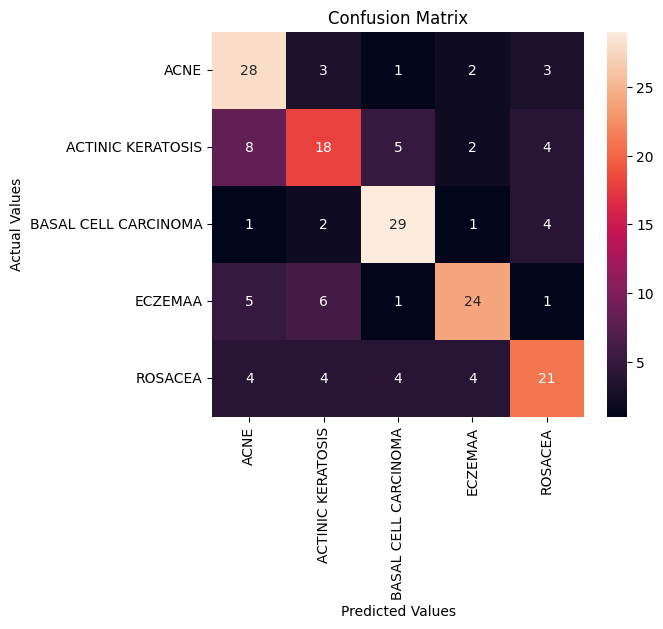

In [ ]:
import pandas as pd
import seaborn as sns

conf_matrix_df = pd.DataFrame(conf_matrix,
                     index = ['ACNE','ACTINIC KERATOSIS','BASAL CELL CARCINOMA','ECZEMAA','ROSACEA'],
                     columns = ['ACNE','ACTINIC KERATOSIS','BASAL CELL CARCINOMA','ECZEMAA','ROSACEA'])

#Plotting the confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix_df, annot=True)
plt.title('Confusion Matrix')
plt.ylabel('Actual Values')
plt.xlabel('Predicted Values')
plt.show()

1/1 [==============================] - 0s 42ms/step


(-0.5, 280.5, 209.5, -0.5)

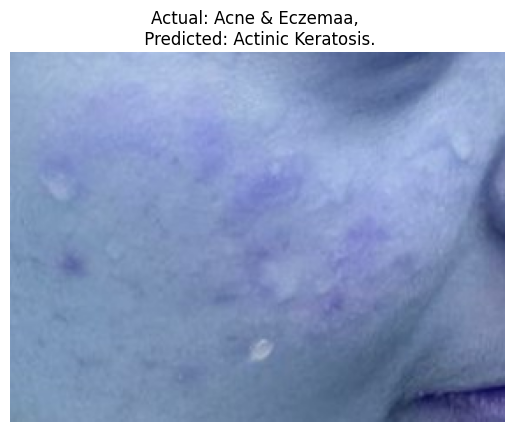

In [ ]:
import cv2

test_img= cv2.imread("/content/drive/MyDrive/SkinClassification/dataset/test_img3.jpg")
# resize_and_rescale(test_img)
# data_augmentation(test_img)
plt.imshow(test_img.astype("uint8"))

predicted_class= predict(model, test_img)
plt.title(f"Actual: Acne & Eczemaa, \n Predicted: {predicted_class}.")
plt.axis("off")


In [ ]:
# model.save("model_resnet50")

In [ ]:
# %cd /content/model_resnet50

In [ ]:
# !cp /content/model_resnet50

In [ ]:
# from google.colab import files
# files.download('/content/model_resnet50')